In [23]:
import torch.nn as nn
import torch

In [24]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm.notebook import tqdm


### Dataset Preparation (MNIST Handwritten)

In [25]:
# Define transformations for MNIST Handwritten
transform_mnist = transforms.Compose([
    transforms.RandomRotation(degrees=10), # random rotation for data augmentation
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST Handwritten training and test datasets
trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)

transform_mnist = transforms.Compose([
    # transforms.RandomRotation(degrees=10), # random rotation for data augmentation
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

# Create data loaders
batch_size = 512
trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=batch_size, shuffle=True, num_workers=2)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"MNIST Handwritten training samples: {len(trainset_mnist)}")
print(f"MNIST Handwritten test samples: {len(testset_mnist)}")

MNIST Handwritten training samples: 60000
MNIST Handwritten test samples: 10000


### Install MedMNIST

In [26]:
!pip install medmnist


### Dataset Preparation (PneumoniaMNIST)

In [27]:
import medmnist
from medmnist import INFO, Evaluator

# Define transformations for PneumoniaMNIST
# Note: MedMNIST datasets are typically 28x28, so resize to 32x32 for LeNet
transform_pneumonia = transforms.Compose([
    transforms.ColorJitter(contrast=0.5),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) # Common normalization for image data
])

# Load PneumoniaMNIST training and test datasets
data_flag = 'pneumoniamnist'
info = INFO[data_flag]

# MedMNIST datasets are typically 1 channel (grayscale) and have num_classes for output_size
# We also need to reshape the labels from (N, 1) to (N,) for CrossEntropyLoss

trainset_pneumonia = medmnist.PneumoniaMNIST(split='train', transform=transform_pneumonia, download=True)
trainset_pneumonia.labels = trainset_pneumonia.labels.squeeze()

transform_pneumonia = transforms.Compose([
    # transforms.ColorJitter(contrast=0.5),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) # Common normalization for image data
])
testset_pneumonia = medmnist.PneumoniaMNIST(split='test', transform=transform_pneumonia, download=True)
testset_pneumonia.labels = testset_pneumonia.labels.squeeze()

# Create data loaders
trainloader_pneumonia = torch.utils.data.DataLoader(trainset_pneumonia, batch_size=batch_size, shuffle=True, num_workers=2)
testloader_pneumonia = torch.utils.data.DataLoader(testset_pneumonia, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"PneumoniaMNIST training samples: {len(trainset_pneumonia)}")
print(f"PneumoniaMNIST test samples: {len(testset_pneumonia)}")

PneumoniaMNIST training samples: 4708
PneumoniaMNIST test samples: 624


### Dataset Preparation (MNIST Fashion)

In [28]:
# Define transformations for MNIST Fashion (same as Handwritten for input size consistency)
transform_fashion = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Common normalization for Fashion MNIST
])

# Load MNIST Fashion training and test datasets
trainset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_fashion)

transform_fashion = transforms.Compose([
    # transforms.RandomRotation(degrees=10),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Common normalization for Fashion MNIST
])

testset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fashion)

# Create data loaders
trainloader_fashion = torch.utils.data.DataLoader(trainset_fashion, batch_size=batch_size, shuffle=True, num_workers=2)
testloader_fashion = torch.utils.data.DataLoader(testset_fashion, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"MNIST Fashion training samples: {len(trainset_fashion)}")
print(f"MNIST Fashion test samples: {len(testset_fashion)}")

MNIST Fashion training samples: 60000
MNIST Fashion test samples: 10000


### Training and Evaluation Functions

In [29]:
def train_model(model, trainloader, criterion, optimizer, num_epochs=10, device='cpu', scheduler=None):
    model.train()
    model.to(device)
    history = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%, LR: {current_lr}')

        if scheduler is not None:
            scheduler.step()

    return history

In [30]:
def evaluate_model(model, testloader, device='cpu', print_metrics=True):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    all_labels = []
    all_predicted = []

    with torch.no_grad():
        for data in tqdm(testloader, desc="[Evaluating]", leave=False):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predicted.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_predicted, average='weighted')
    recall = recall_score(all_labels, all_predicted, average='weighted')
    precision = precision_score(all_labels, all_predicted, average='weighted')

    if print_metrics:
        print(f'Accuracy on the test set: {accuracy:.2f}%')
        print(f'F1-Score (weighted): {f1:.2f}')
        print(f'Recall (weighted): {recall:.2f}')
        print(f'Precision (weighted): {precision:.2f}')

    return accuracy, f1, recall, precision

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

def plot_history(history, title="Training History"):
    """Vẽ biểu đồ Loss và Accuracy từ lịch sử huấn luyện"""
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(history['loss'], color='tab:red', label='Loss')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color='tab:blue')
    ax2.plot(history['acc'], color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title)
    fig.tight_layout()
    plt.show()

def plot_confusion_matrix(model, testloader, device, classes, title="Confusion Matrix"):
    """Dự đoán và vẽ ma trận nhầm lẫn"""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

In [32]:
# changing the lenet with newer code style -> increase nums of params but it may be better, and have no different about speed

class Lenet(nn.Module):
  def __init__(self, input_size, output_size): # the input size should be 32 with padding
    super(Lenet, self).__init__()

    self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
    self.bn1 = nn.BatchNorm2d(6) # BN cho 6 kênh của C1
    self.s2 = nn.MaxPool2d(2, 2)
    self.c3 = nn.Conv2d(6, 16, kernel_size=5,stride=1)
    self.bn3 = nn.BatchNorm2d(16) # BN cho 16 kênh sau khi cat ở C3
    self.s4 = nn.MaxPool2d(2, 2)
    self.c5 = nn.Conv2d(16, 120, stride=1, kernel_size=5)
    self.bn5 = nn.BatchNorm2d(120)
    self.fc6 = nn.Linear(120, 84)
    self.bn6 = nn.BatchNorm1d(84)

    self.output = nn.Linear(84, output_size)

  def forward(self, x):

    # Inserts a dimension with a size of one (a singleton dimension) into the tensor's shape.
    if x.dim() == 3:
      x = x.unsqueeze(0)

    x = self.bn1(self.c1(x))
    x = torch.relu(self.s2(x))
    x = self.bn3(self.c3(x))
    x = torch.relu(self.s4(x))
    x = self.bn5(self.c5(x))

    # x is now of shape (N, 120, 1, 1) and need to be at shape (N, 120) to proceed so we use x.view

    x = x.view(x.shape[0], -1)

    x = torch.relu(self.bn6(self.fc6(x)))

    return self.output(x)


In [33]:
# changing the lenet with newer code style -> increase nums of params but it may be better, and have no different about speed

class LenetDropout(nn.Module):
  def __init__(self, input_size, output_size): # the input size should be 32 with padding
    super(LenetDropout, self).__init__()

    self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
    self.bn1 = nn.BatchNorm2d(6) # BN cho 6 kênh của C1
    self.s2 = nn.MaxPool2d(2, 2)
    self.c3 = nn.Conv2d(6, 16, kernel_size=5,stride=1)
    self.bn3 = nn.BatchNorm2d(16) # BN cho 16 kênh sau khi cat ở C3
    self.s4 = nn.MaxPool2d(2, 2)
    self.c5 = nn.Conv2d(16, 120, stride=1, kernel_size=5)
    self.bn5 = nn.BatchNorm2d(120)
    self.fc6 = nn.Linear(120, 84)
    self.bn6 = nn.BatchNorm1d(84)

    self.output = nn.Linear(84, output_size)

    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    if x.dim() == 3:
        x = x.unsqueeze(0)

    # --- Khối 1 ---
    x = self.c1(x)
    x = self.bn1(x)
    x = torch.relu(x)      # Kích hoạt (lọc nhiễu âm) TRƯỚC
    x = self.s2(x)         # Pooling (nén đặc trưng) SAU

    # --- Khối 2 ---
    x = self.c3(x)
    x = self.bn3(x)
    x = torch.relu(x)      # Kích hoạt TRƯỚC
    x = self.s4(x)         # Pooling SAU

    # --- Khối 3 ---
    x = self.c5(x)
    x = self.bn5(x)
    x = torch.relu(x)

    # --- Flatten ---
    x = x.view(x.shape[0], -1)

    # --- Khối FC ---
    x = self.fc6(x)
    x = self.bn6(x)
    x = torch.relu(x)
    x = self.dropout(x)    # Dropout 0.5 hoạt động cực tốt ở đây

    return self.output(x)

In [34]:
from sklearn.metrics import f1_score, recall_score, precision_score

### LeNet on MNIST Handwritten


--- Training LeNet on MNIST Handwritten ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.1657, Acc: 95.39%, LR: 0.01


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.0623, Acc: 98.02%, LR: 0.01


...

Epoch 28, Loss: 0.0112, Acc: 99.65%, LR: 0.0001


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0116, Acc: 99.68%, LR: 0.0001


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0109, Acc: 99.68%, LR: 0.0001


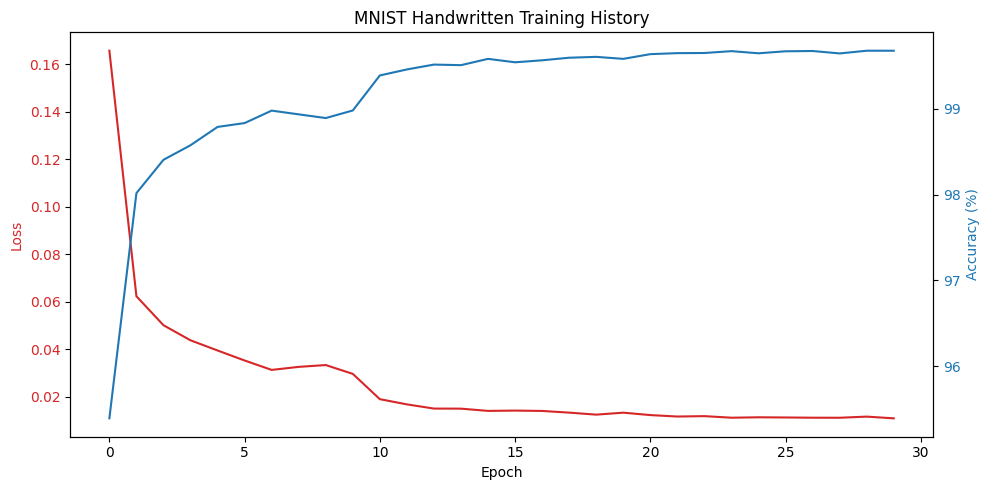

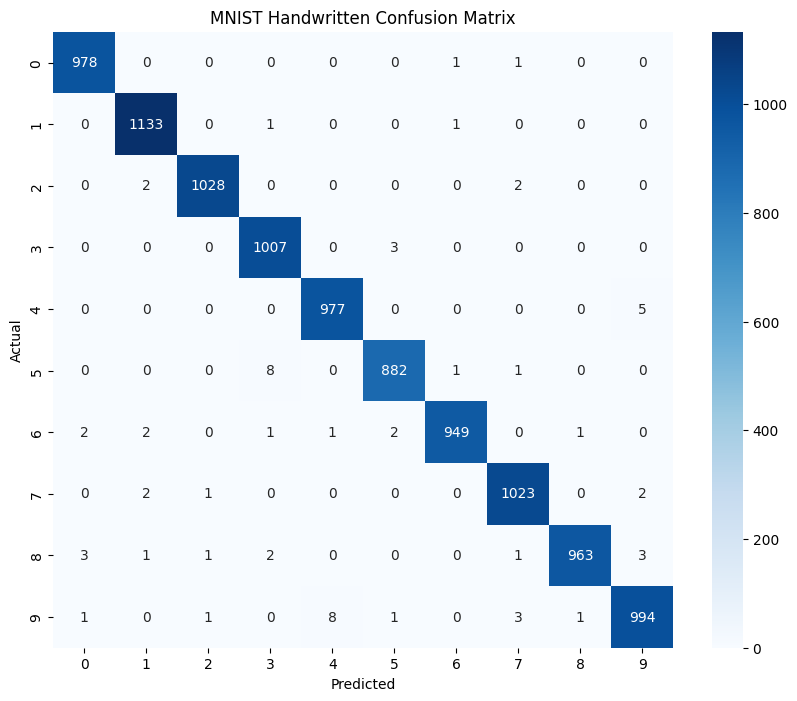

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 99.34%
F1-Score (weighted): 0.99
Recall (weighted): 0.99
Precision (weighted): 0.99


In [35]:
print("\n--- Training LeNet on MNIST Handwritten ---")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lenet_mnist = Lenet(input_size=32, output_size=10)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(lenet_mnist.parameters(), lr=0.01)
# Khởi tạo scheduler
scheduler_mnist = optim.lr_scheduler.StepLR(optimizer_mnist, step_size=10, gamma=0.1)

# Huấn luyện với scheduler
history_mnist = train_model(lenet_mnist, trainloader_mnist, criterion_mnist, optimizer_mnist, num_epochs=30, device=device, scheduler=scheduler_mnist)
plot_history(history_mnist, title="MNIST Handwritten Training History")

classes_mnist = [str(i) for i in range(10)]
plot_confusion_matrix(lenet_mnist, testloader_mnist, device, classes_mnist, title="MNIST Handwritten Confusion Matrix")
accuracy_mnist, f1_mnist, recall_mnist, precision_mnist = evaluate_model(lenet_mnist, testloader_mnist, device=device)

In [36]:
accuracy_mnist, f1_mnist, recall_mnist, precision_mnist = evaluate_model(lenet_mnist, testloader_mnist, device=device)

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 99.34%
F1-Score (weighted): 0.99
Recall (weighted): 0.99
Precision (weighted): 0.99


### LeNet on MNIST Fashion

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
# LeNetWide class definition with fix
class LeNetWide(nn.Module):
    def __init__(self, output_size=10):
        super(LeNetWide, self).__init__()

        # --- Khối 1: Tăng từ 6 lên 32 filters ---
        # Input: 28x28. Thêm padding=2 để ảnh lên 32x32 -> Output: 32 channels, 28x28
        self.c1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.s2 = nn.MaxPool2d(2, 2) # Output: 32 channels, 14x14

        # --- Khối 2: Tăng từ 16 lên 64 filters ---
        # Dùng Conv2d tiêu chuẩn thay vì c3_indices phức tạp
        self.c3 = nn.Conv2d(32, 64, kernel_size=5) # Output: 64 channels, 10x10
        self.bn3 = nn.BatchNorm2d(64)
        self.s4 = nn.MaxPool2d(2, 2) # Output: 64 channels, 5x5

        # --- Khối 3: Tăng từ 120 lên 256 filters ---
        self.c5 = nn.Conv2d(64, 256, kernel_size=5) # Output: 256 channels, 1x1
        self.bn5 = nn.BatchNorm2d(256)

        # --- Khối Fully Connected: Tăng từ 84 lên 128 ---
        # FIX: Changed input features from 256 to 1024
        self.fc6 = nn.Linear(1024, 128)
        self.bn6 = nn.BatchNorm1d(128)

        self.output = nn.Linear(128, output_size)

        # Dropout 0.5 để chống overfit do lượng tham số đã tăng lên nhiều
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(0)

        # Khối 1
        x = self.c1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.s2(x)

        # Khối 2
        x = self.c3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.s4(x)

        # Khối 3
        x = self.c5(x)
        x = self.bn5(x)
        x = torch.relu(x)

        # Flatten [Batch, 256, 1, 1] -> [Batch, 256]
        x = x.view(x.size(0), -1)

        # Khối FC
        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)
        x = self.dropout(x)

        return self.output(x)


--- Training LeNet on MNIST Fashion ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5433, Acc: 82.49%, LR: 0.001


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3359, Acc: 88.36%, LR: 0.001


...

Epoch 28, Loss: 0.1090, Acc: 96.09%, LR: 1e-05


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.1124, Acc: 96.02%, LR: 1e-05


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.1113, Acc: 96.04%, LR: 1e-05


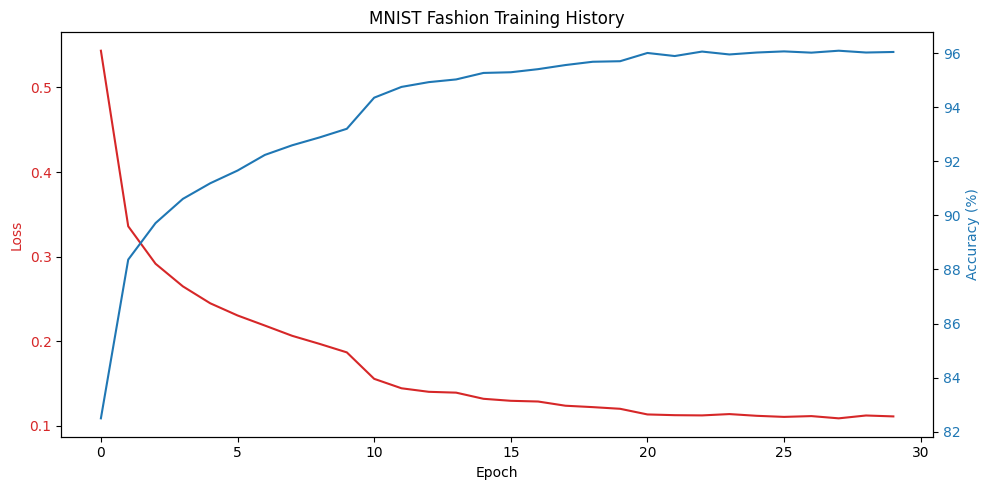

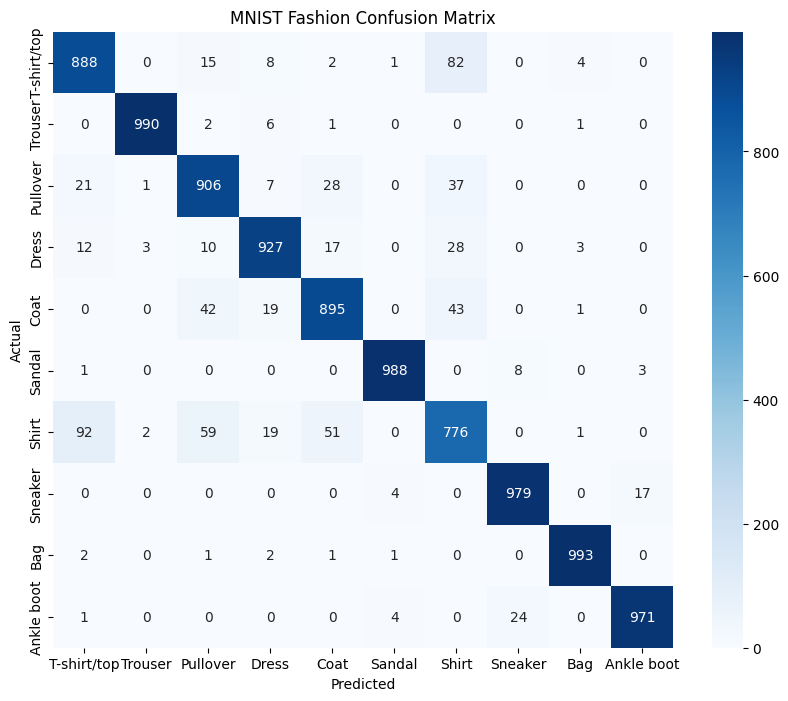

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 93.13%
F1-Score (weighted): 0.93
Recall (weighted): 0.93
Precision (weighted): 0.93


In [38]:


print("\n--- Training LeNet on MNIST Fashion ---")
lenet_fashion = LeNetWide(output_size=10)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_fashion = optim.Adam(lenet_fashion.parameters(), lr=0.001)
scheduler_fashion = optim.lr_scheduler.StepLR(optimizer_fashion, step_size=10, gamma=0.1)

history_fashion = train_model(lenet_fashion, trainloader_fashion, criterion_fashion, optimizer_fashion, num_epochs=30, device=device, scheduler=scheduler_fashion)
plot_history(history_fashion, title="MNIST Fashion Training History")

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plot_confusion_matrix(lenet_fashion, testloader_fashion, device, classes_fashion, title="MNIST Fashion Confusion Matrix")
accuracy_fashion, f1_fashion, recall_fashion, precision_fashion = evaluate_model(lenet_fashion, testloader_fashion, device=device)

In [39]:
import torch
import torch.nn as nn

class LeNetWide_3x3(nn.Module):
    def __init__(self, output_size=10):
        super(LeNetWide_3x3, self).__init__()

        # Khối 1: Dùng kernel 3x3, padding 1
        self.c1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.s2 = nn.MaxPool2d(2, 2)

        # Khối 2: Tăng filter lên 64, kernel 3x3
        self.c3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.s4 = nn.MaxPool2d(2, 2)

        # Khối 3: Tăng filter lên 128, kernel 3x3
        self.c5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        # ĐIỂM SÁNG: Ép đầu ra của C5 luôn về kích thước 2x2 bất kể ảnh gốc như thế nào
        self.pool_final = nn.AdaptiveAvgPool2d((2, 2))

        # FC Layer: 128 kênh x kích thước 2x2 = 512
        self.fc6 = nn.Linear(128 * 2 * 2, 128)
        self.bn6 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)

        self.output = nn.Linear(128, output_size)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(0)

        # Block 1
        x = self.s2(torch.relu(self.bn1(self.c1(x))))
        # Block 2
        x = self.s4(torch.relu(self.bn3(self.c3(x))))
        # Block 3
        x = torch.relu(self.bn5(self.c5(x)))

        # Ép về 2x2
        x = self.pool_final(x)

        # Flatten (Batch_size, 128 * 2 * 2)
        x = x.view(x.size(0), -1)

        # FC Block
        x = self.dropout(torch.relu(self.bn6(self.fc6(x))))

        return self.output(x)


--- Training LeNet on MNIST Fashion ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.6274, Acc: 80.30%, LR: 0.001


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3631, Acc: 87.51%, LR: 0.001


...

Epoch 28, Loss: 0.1738, Acc: 93.81%, LR: 1e-05


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.1718, Acc: 93.75%, LR: 1e-05


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.1711, Acc: 93.95%, LR: 1e-05


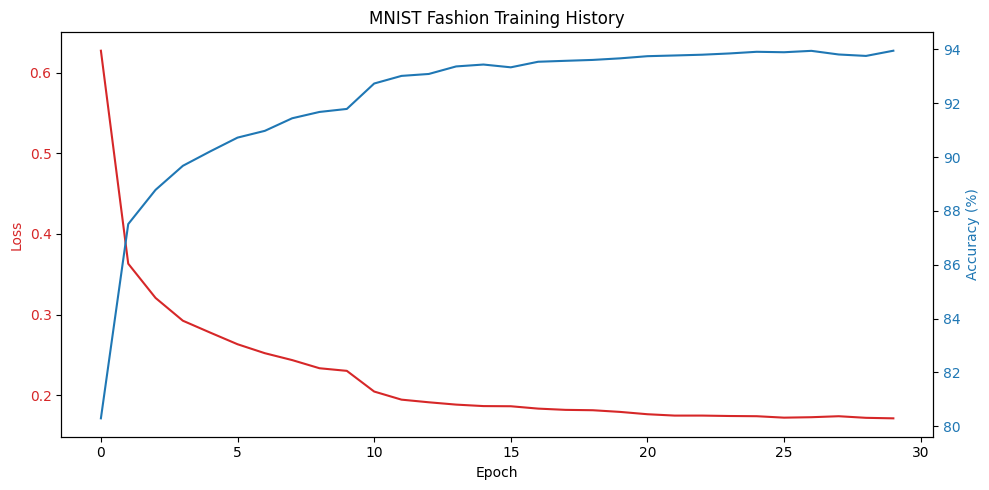

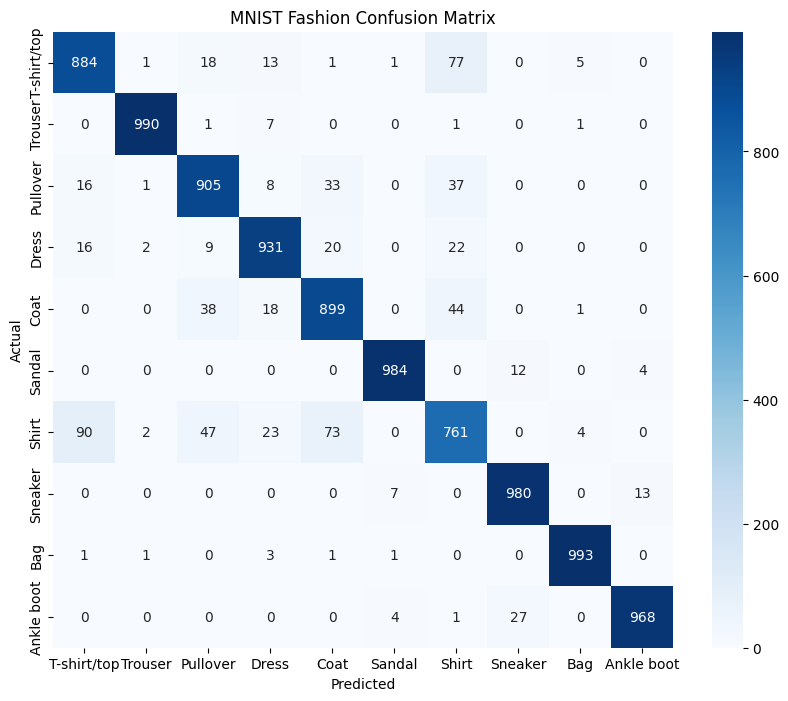

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 92.95%
F1-Score (weighted): 0.93
Recall (weighted): 0.93
Precision (weighted): 0.93


In [40]:


print("\n--- Training LeNet on MNIST Fashion ---")
lenet_fashion = LeNetWide_3x3(output_size=10)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_fashion = optim.Adam(lenet_fashion.parameters(), lr=0.001)
scheduler_fashion = optim.lr_scheduler.StepLR(optimizer_fashion, step_size=10, gamma=0.1)

history_fashion = train_model(lenet_fashion, trainloader_fashion, criterion_fashion, optimizer_fashion, num_epochs=30, device=device, scheduler=scheduler_fashion)
plot_history(history_fashion, title="MNIST Fashion Training History")

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plot_confusion_matrix(lenet_fashion, testloader_fashion, device, classes_fashion, title="MNIST Fashion Confusion Matrix")
accuracy_fashion, f1_fashion, recall_fashion, precision_fashion = evaluate_model(lenet_fashion, testloader_fashion, device=device)

### LeNet on PneumoniaMNIST


--- Training LeNet on PneumoniaMNIST ---


Epoch 1/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1, Loss: 0.7073, Acc: 68.31%, LR: 0.01


Epoch 2/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3352, Acc: 82.50%, LR: 0.01


...

Epoch 28, Loss: 0.0771, Acc: 96.81%, LR: 0.0001


Epoch 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0907, Acc: 96.71%, LR: 0.0001


Epoch 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0839, Acc: 96.60%, LR: 0.0001


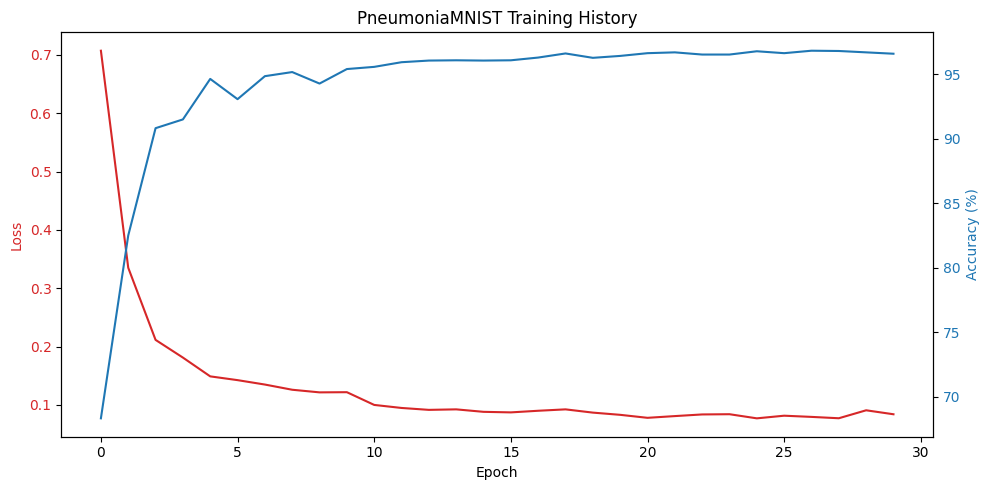

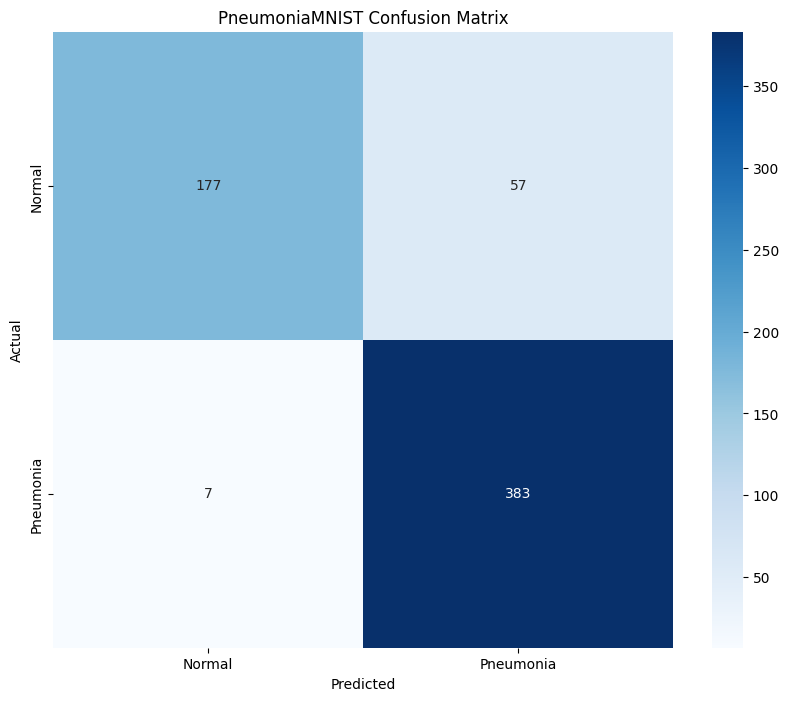

[Evaluating]:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 89.74%
F1-Score (weighted): 0.89
Recall (weighted): 0.90
Precision (weighted): 0.90


In [41]:
print("\n--- Training LeNet on PneumoniaMNIST ---")
# Calculate class weights for PneumoniaMNIST
class_counts = torch.bincount(torch.tensor(trainset_pneumonia.labels))
total_samples = class_counts.sum().item()
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts.float())
class_weights = class_weights.to(device)

lenet_pneumonia = LeNetWide_3x3(output_size=2)
criterion_pneumonia = nn.CrossEntropyLoss(weight=class_weights) # Apply weighted loss
optimizer_pneumonia = optim.Adam(lenet_pneumonia.parameters(), lr=0.01)
scheduler_pneumonia = optim.lr_scheduler.StepLR(optimizer_pneumonia, step_size=10, gamma=0.1)

history_pneumonia = train_model(lenet_pneumonia, trainloader_pneumonia, criterion_pneumonia, optimizer_pneumonia, num_epochs=30, device=device, scheduler=scheduler_pneumonia)
plot_history(history_pneumonia, title="PneumoniaMNIST Training History")

classes_pneumonia = ['Normal', 'Pneumonia']
plot_confusion_matrix(lenet_pneumonia, testloader_pneumonia, device, classes_pneumonia, title="PneumoniaMNIST Confusion Matrix")
accuracy_pneumonia, f1_pneumonia, recall_pneumonia, precision_pneumonia = evaluate_model(lenet_pneumonia, testloader_pneumonia, device=device)


--- Training LeNet on PneumoniaMNIST ---


Epoch 1/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5332, Acc: 73.15%, LR: 0.01


Epoch 2/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2, Loss: 0.2402, Acc: 88.91%, LR: 0.01


...

Epoch 28, Loss: 0.0435, Acc: 98.34%, LR: 0.0001


Epoch 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0432, Acc: 98.28%, LR: 0.0001


Epoch 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0476, Acc: 98.24%, LR: 0.0001


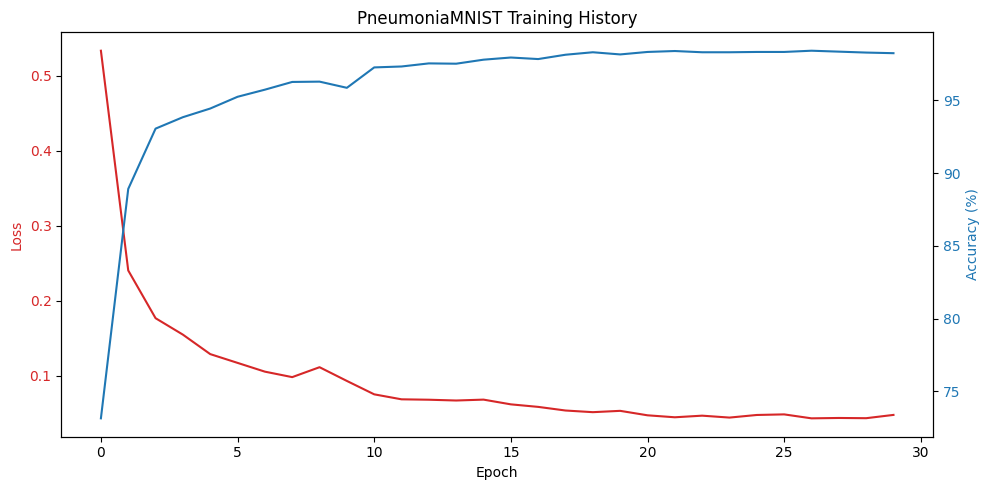

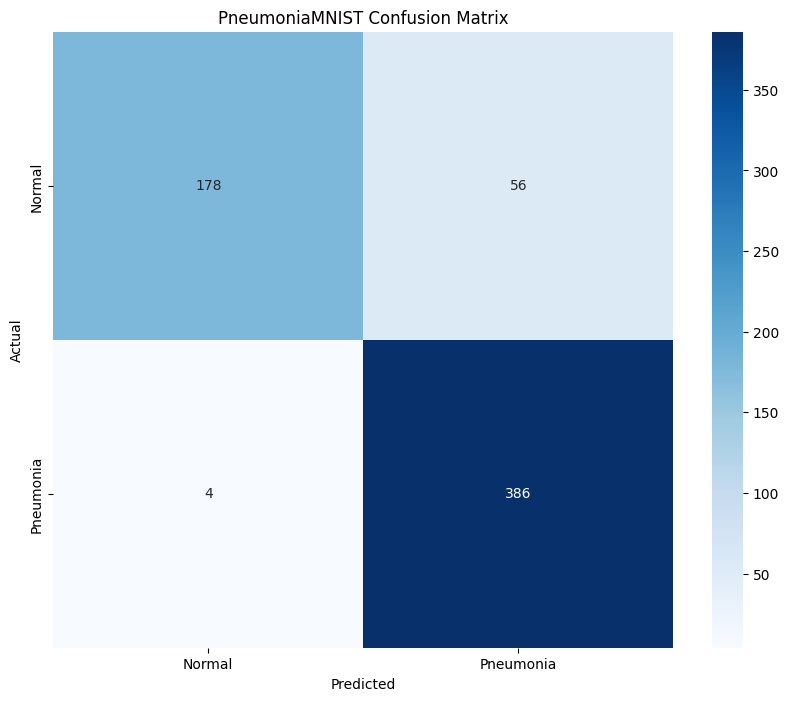

[Evaluating]:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 90.38%
F1-Score (weighted): 0.90
Recall (weighted): 0.90
Precision (weighted): 0.91


In [46]:
print("\n--- Training LeNet on PneumoniaMNIST ---")
# Calculate class weights for PneumoniaMNIST
class_counts = torch.bincount(torch.tensor(trainset_pneumonia.labels))
total_samples = class_counts.sum().item()
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts.float())
class_weights = class_weights.to(device)

lenet_pneumonia = LeNetWide(output_size=2)
criterion_pneumonia = nn.CrossEntropyLoss(weight=class_weights) # Apply weighted loss
optimizer_pneumonia = optim.Adam(lenet_pneumonia.parameters(), lr=0.01)
scheduler_pneumonia = optim.lr_scheduler.StepLR(optimizer_pneumonia, step_size=10, gamma=0.1)

history_pneumonia = train_model(lenet_pneumonia, trainloader_pneumonia, criterion_pneumonia, optimizer_pneumonia, num_epochs=30, device=device, scheduler=scheduler_pneumonia)
plot_history(history_pneumonia, title="PneumoniaMNIST Training History")

classes_pneumonia = ['Normal', 'Pneumonia']
plot_confusion_matrix(lenet_pneumonia, testloader_pneumonia, device, classes_pneumonia, title="PneumoniaMNIST Confusion Matrix")
accuracy_pneumonia, f1_pneumonia, recall_pneumonia, precision_pneumonia = evaluate_model(lenet_pneumonia, testloader_pneumonia, device=device)

In [47]:
import torch

# Save LeNet on MNIST Handwritten model
torch.save(lenet_mnist.state_dict(), 'lenet_mnist_handwritten.pth')
print("LeNet on MNIST Handwritten model saved to lenet_mnist_handwritten.pth")

# Save LeNet on MNIST Fashion model
torch.save(lenet_fashion.state_dict(), 'lenet_mnist_fashion.pth')
print("LeNet on MNIST Fashion model saved to lenet_mnist_fashion.pth")

# Save LeNet on PneumoniaMNIST model
torch.save(lenet_pneumonia.state_dict(), 'lenet_pneumonia.pth')
print("LeNet on PneumoniaMNIST model saved to lenet_pneumonia.pth")

LeNet on MNIST Handwritten model saved to lenet_mnist_handwritten.pth
LeNet on MNIST Fashion model saved to lenet_mnist_fashion.pth
LeNet on PneumoniaMNIST model saved to lenet_pneumonia.pth


In [48]:
import numpy as np

def find_most_confused_classes(all_labels, all_predicted, num_pairs=2):
    cm = confusion_matrix(all_labels, all_predicted)
    np.fill_diagonal(cm, 0) # Set diagonal to 0 to ignore correct predictions

    # Flatten the matrix and get indices of largest values
    # argsort returns indices that would sort an array
    # We need to unravel_index to convert flat indices to 2D coordinates
    flat_indices = np.argsort(cm.ravel())[::-1] # Get indices of largest values in flattened array, descending

    most_confused_pairs = []
    for idx in flat_indices:
        true_idx, pred_idx = np.unravel_index(idx, cm.shape)
        if cm[true_idx, pred_idx] > 0: # Only consider actual misclassifications
            most_confused_pairs.append((true_idx, pred_idx))
        if len(most_confused_pairs) == num_pairs:
            break
    return most_confused_pairs

def plot_misclassified_samples(model, testloader, device, classes, true_class_idx, pred_class_idx, num_samples=5, title="Misclassified Samples"):
    model.eval()
    misclassified_images = []
    count = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            for i in range(len(labels)):
                if labels[i] == true_class_idx and predicted[i] == pred_class_idx:
                    misclassified_images.append((images[i].cpu(), labels[i].cpu().item(), predicted[i].cpu().item()))
                    count += 1
                    if count >= num_samples:
                        break
            if count >= num_samples:
                break

    if not misclassified_images:
        print(f"No samples found where true label is '{classes[true_class_idx]}' and predicted label is '{classes[pred_class_idx]}'")
        return

    fig = plt.figure(figsize=(12, 2 * num_samples) if num_samples > 0 else (12,2))
    plt.suptitle(f'{title}: True "{classes[true_class_idx]}" predicted as "{classes[pred_class_idx]}"', fontsize=16)

    for i, (image, true_label, pred_label) in enumerate(misclassified_images):
        if i >= num_samples: break
        ax = fig.add_subplot(1, num_samples, i + 1, xticks=[], yticks=[])
        image = image.squeeze().numpy() # Remove channel dimension and convert to numpy
        ax.imshow(image, cmap='gray')
        ax.set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}', color='red')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


--- Analyzing LeNet on MNIST Handwritten ---
Most confused classes for MNIST Handwritten: [(np.int64(9), np.int64(4)), (np.int64(5), np.int64(3))]


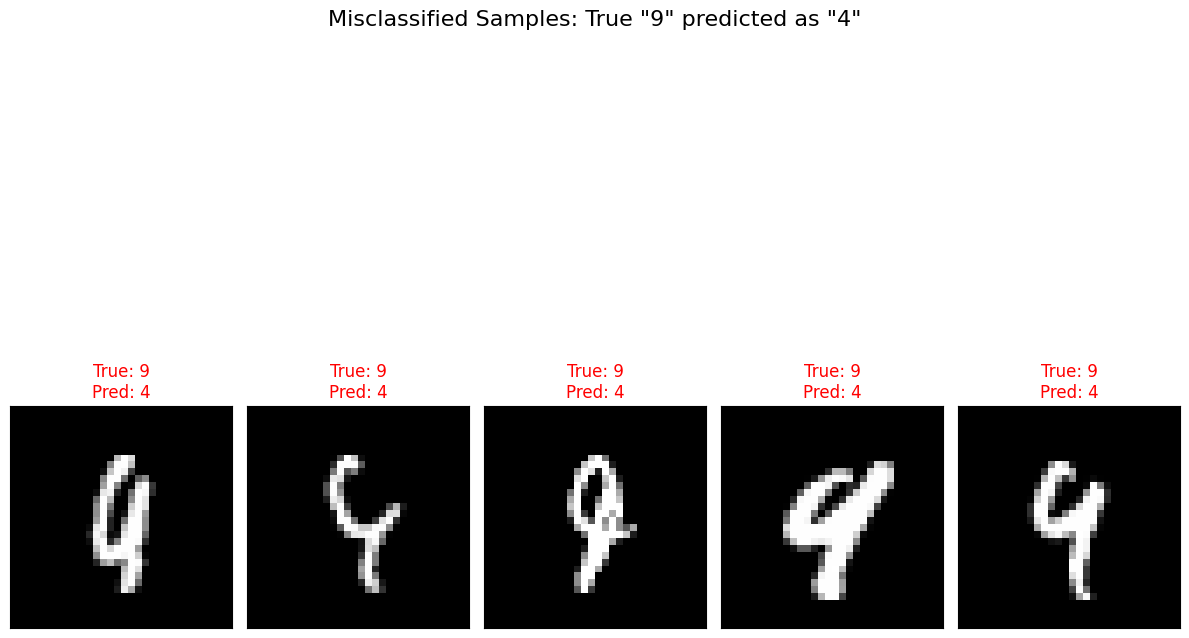

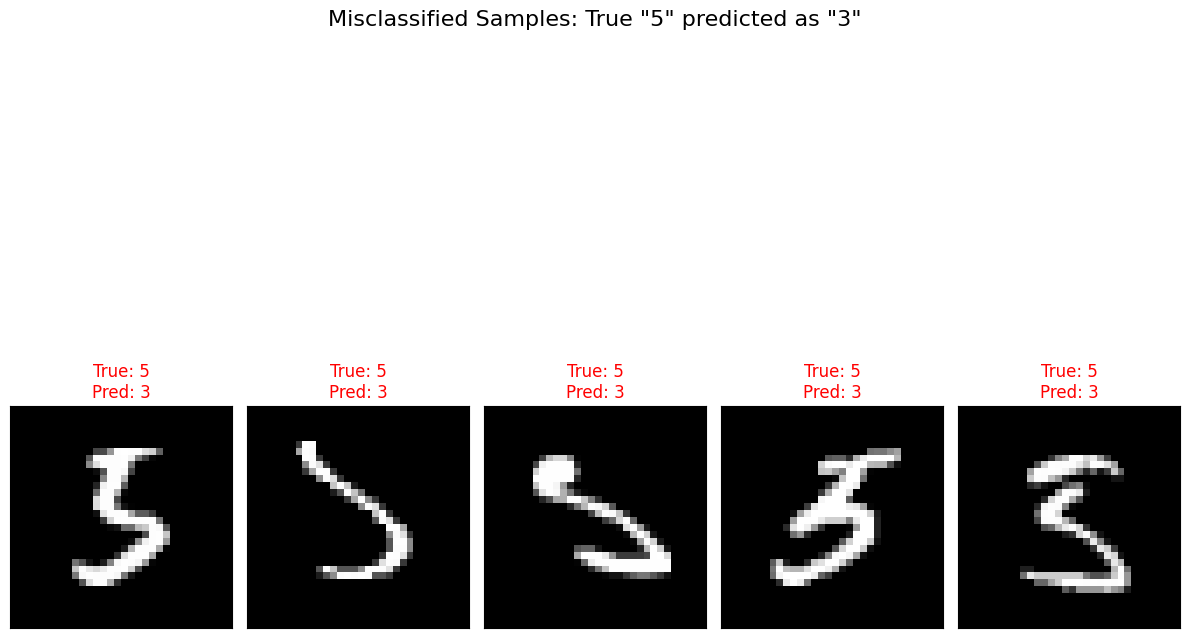


--- Analyzing LeNet on MNIST Fashion ---
Most confused classes for MNIST Fashion: [(np.int64(6), np.int64(0)), (np.int64(0), np.int64(6))]


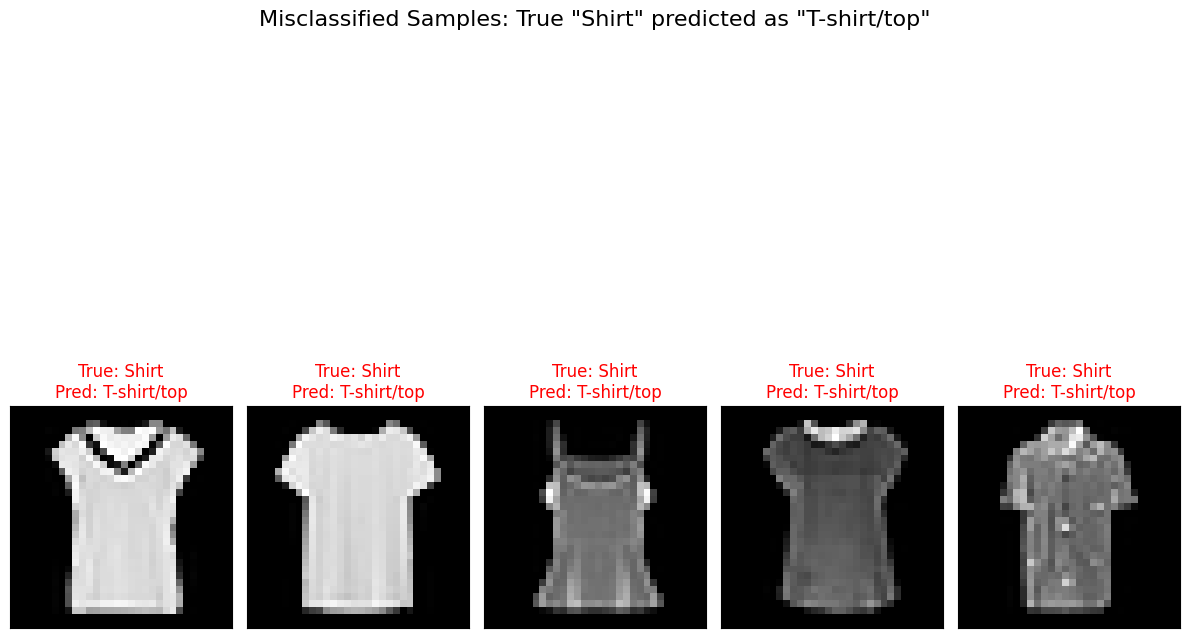

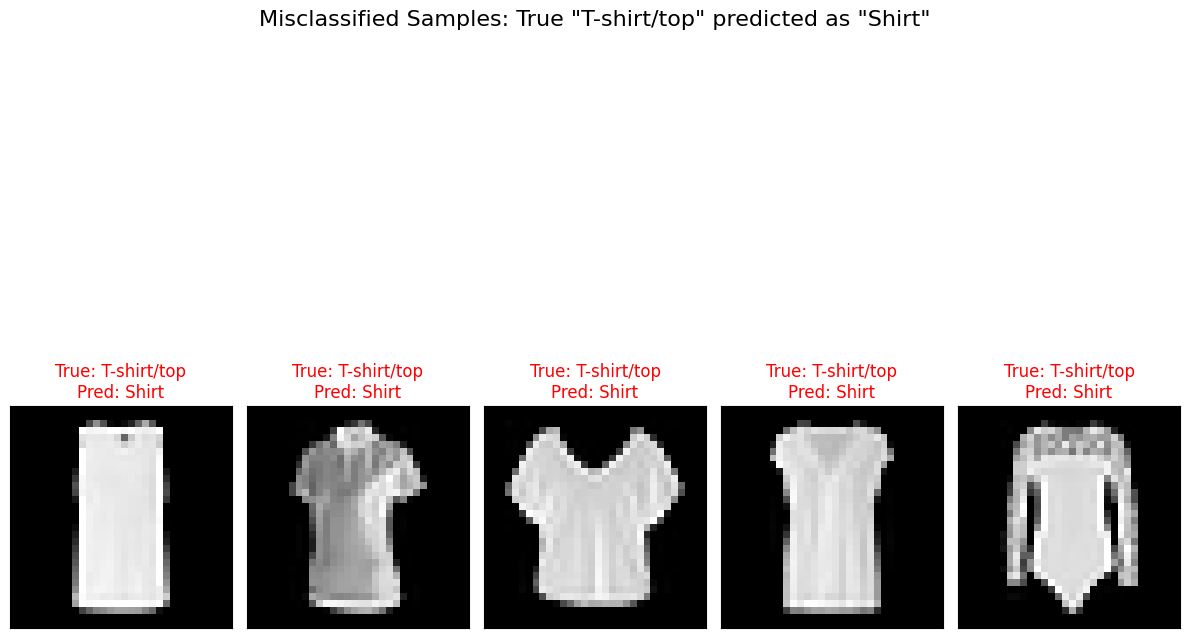


--- Analyzing LeNet on PneumoniaMNIST ---
Most confused classes for PneumoniaMNIST: [(np.int64(0), np.int64(1)), (np.int64(1), np.int64(0))]


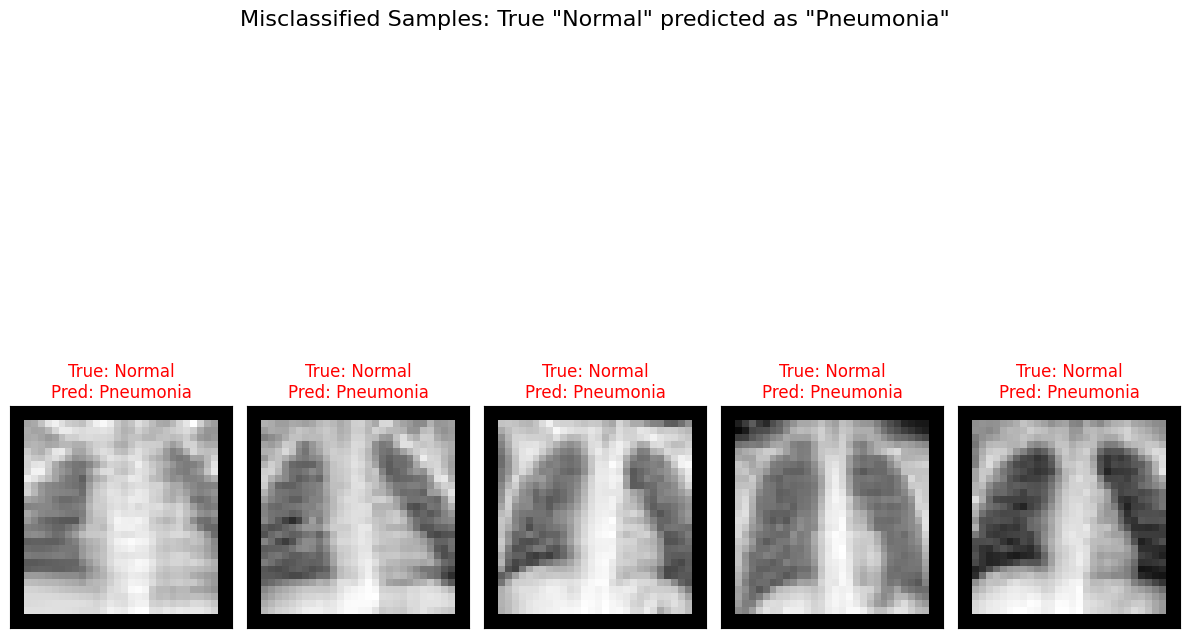

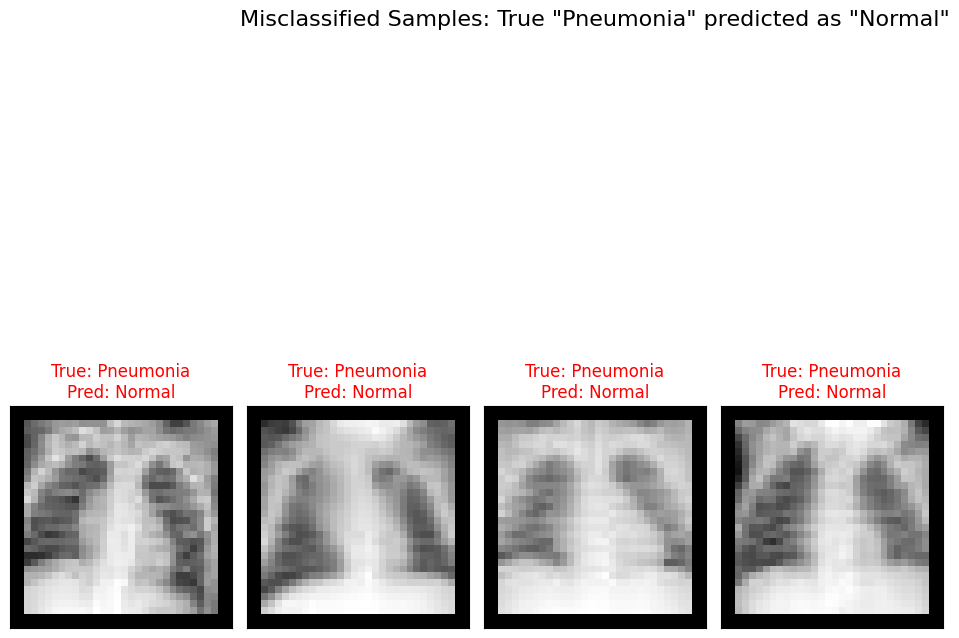

In [51]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def get_predictions(model, testloader, device):
    model.eval()
    all_labels = []
    all_predicted = []
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_predicted

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- Load and Evaluate LeNet on MNIST Handwritten ---
print("\n--- Analyzing LeNet on MNIST Handwritten ---")
lenet_mnist_loaded = Lenet(input_size=32, output_size=10).to(device)
lenet_mnist_loaded.load_state_dict(torch.load('lenet_mnist_handwritten.pth'))

all_labels_mnist, all_predicted_mnist = get_predictions(lenet_mnist_loaded, testloader_mnist, device)
most_confused_mnist = find_most_confused_classes(all_labels_mnist, all_predicted_mnist, num_pairs=2)

classes_mnist = [str(i) for i in range(10)]
if most_confused_mnist:
    print(f"Most confused classes for MNIST Handwritten: {most_confused_mnist}")
    for true_idx, pred_idx in most_confused_mnist:
        plot_misclassified_samples(lenet_mnist_loaded, testloader_mnist, device, classes_mnist, true_idx, pred_idx, num_samples=5)
else:
    print("No significant misclassifications found for MNIST Handwritten.")


# --- Load and Evaluate LeNet on MNIST Fashion ---
print("\n--- Analyzing LeNet on MNIST Fashion ---")
lenet_fashion_loaded = LeNetWide_3x3(output_size=10).to(device) # Assuming LeNetWide_3x3 was used last
lenet_fashion_loaded.load_state_dict(torch.load('lenet_mnist_fashion.pth'))

all_labels_fashion, all_predicted_fashion = get_predictions(lenet_fashion_loaded, testloader_fashion, device)
most_confused_fashion = find_most_confused_classes(all_labels_fashion, all_predicted_fashion, num_pairs=2)

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
if most_confused_fashion:
    print(f"Most confused classes for MNIST Fashion: {most_confused_fashion}")
    for true_idx, pred_idx in most_confused_fashion:
        plot_misclassified_samples(lenet_fashion_loaded, testloader_fashion, device, classes_fashion, true_idx, pred_idx, num_samples=5)
else:
    print("No significant misclassifications found for MNIST Fashion.")


# --- Load and Evaluate LeNet on PneumoniaMNIST ---
print("\n--- Analyzing LeNet on PneumoniaMNIST ---")
lenet_pneumonia_loaded = LeNetWide(output_size=2).to(device) # Assuming LeNetWide_3x3 was used last
lenet_pneumonia_loaded.load_state_dict(torch.load('lenet_pneumonia.pth'))

all_labels_pneumonia, all_predicted_pneumonia = get_predictions(lenet_pneumonia_loaded, testloader_pneumonia, device)
most_confused_pneumonia = find_most_confused_classes(all_labels_pneumonia, all_predicted_pneumonia, num_pairs=2)

classes_pneumonia = ['Normal', 'Pneumonia']
if most_confused_pneumonia:
    print(f"Most confused classes for PneumoniaMNIST: {most_confused_pneumonia}")
    for true_idx, pred_idx in most_confused_pneumonia:
        plot_misclassified_samples(lenet_pneumonia_loaded, testloader_pneumonia, device, classes_pneumonia, true_idx, pred_idx, num_samples=5)
else:
    print("No significant misclassifications found for PneumoniaMNIST.")